In [2]:
import ctypes
import numpy as np
import numpy.ctypeslib


# Chargement de la bibliothèque Rust
rust_path = "../my_lib/target/release/deps/libmy_lib.so"
my_lib = ctypes.cdll.LoadLibrary(rust_path)

# Create ConvLayer
my_lib.create_ConvLayer.argtypes = [ctypes.c_int32, #input_depth
                                    ctypes.c_int32, #input_height
                                    ctypes.c_int32, #input_width
                                    ctypes.c_int32, #kernel_size
                                    ctypes.c_int32] #n_kernels
my_lib.create_ConvLayer.restype = ctypes.c_void_p

# Create DenseLayer
my_lib.create_DenseLayer.argtypes = [ctypes.c_int32, #input_size
                                    ctypes.c_int32] #output_size
my_lib.create_DenseLayer.restype = ctypes.c_void_p

# Create FlattenLayer
my_lib.create_FlattenLayer.argtypes = []
my_lib.create_FlattenLayer.restype = ctypes.c_void_p

# Create ActivationLayer
my_lib.create_ActivationLayer.argtypes = [ctypes.c_char_p] #activation_name
my_lib.create_ActivationLayer.restype = ctypes.c_void_p

# Create MaxPoolingLayer
my_lib.create_MaxPoolingLayer.argtypes = [ctypes.c_int32] #pool_size
my_lib.create_MaxPoolingLayer.restype = ctypes.c_void_p

#Create MyCNN
my_lib.create_MyCNN.argtypes = [ctypes.POINTER(ctypes.c_void_p), #network
                                ctypes.c_int32, #network_size
                               ctypes.c_char_p] #loss_name
my_lib.create_MyCNN.restype = ctypes.c_void_p


#train_MyCNN
my_lib.train_MyCNN.argtypes = [ctypes.c_void_p, #model
                               
                               ctypes.POINTER(ctypes.c_double), #X_train
                               ctypes.c_int32, # n_images_train
                               ctypes.c_int32, # image_depth
                               ctypes.c_int32, # image_height
                               ctypes.c_int32, # image_width
                               
                               ctypes.POINTER(ctypes.c_double),  # y_train
                               ctypes.c_int32,  # y_dim
                               
                               ctypes.POINTER(ctypes.c_double), #X_test
                               ctypes.c_int32, # n_images_test

                               ctypes.POINTER(ctypes.c_double), #y_test

                               ctypes.c_double,
                                ctypes.c_int32]

#predict_MyCNN
my_lib.predict_MyCNN.argtypes = [ctypes.c_void_p, #model
                               
                               ctypes.POINTER(ctypes.c_double), #X
                               ctypes.c_int32, # n_images
                               ctypes.c_int32, # image_depth
                               ctypes.c_int32, # image_height
                               ctypes.c_int32] # image_width                   
my_lib.predict_MyCNN.restype = ctypes.POINTER(ctypes.c_double)

#get_train_losses_MyCNN
my_lib.get_train_losses_MyCNN.argtypes = [ctypes.c_void_p]
my_lib.get_train_losses_MyCNN.restype = ctypes.POINTER(ctypes.c_double)

#get_test_losses_MyCNN
my_lib.get_test_losses_MyCNN.argtypes = [ctypes.c_void_p]
my_lib.get_test_losses_MyCNN.restype = ctypes.POINTER(ctypes.c_double)

my_lib.save_MyCNN.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_char)]

my_lib.load_MyCNN.argtypes = [ctypes.POINTER(ctypes.c_char)]
my_lib.load_MyCNN.restype = ctypes.c_void_p

my_lib.my_correlate2d.argtypes = [
    ctypes.POINTER(ctypes.c_double), ctypes.c_size_t, ctypes.c_size_t,
    ctypes.POINTER(ctypes.c_double), ctypes.c_size_t,
    ctypes.POINTER(ctypes.c_uint8), ctypes.c_size_t
]
my_lib.my_correlate2d.restype = ctypes.POINTER(ctypes.c_double)

# Emotion data training

Nombre de photos récupérées pour happy : 10
Nombre de photos récupérées pour neutral : 10
Nombre de photos récupérées pour sad : 10
X_train shape: (21, 64, 64, 3)
y_train shape: (21, 3)
X_test shape: (9, 64, 64, 3)
y_test shape: (9, 3)


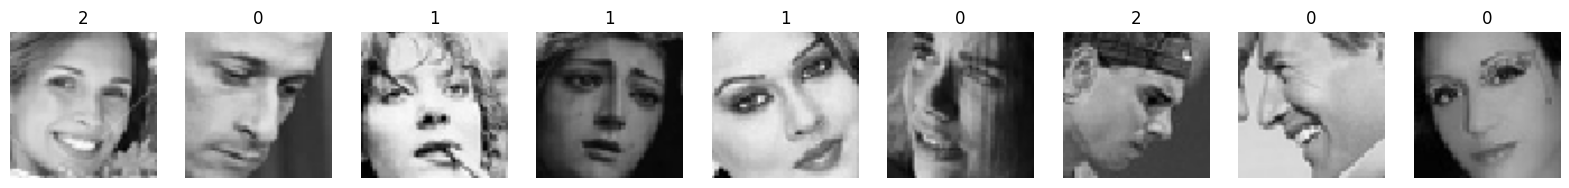

In [192]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

def load_emotions_data(path, image_size, nombre_d_images_par_classe):
    emotions = ['happy', 'neutral', 'sad']
    X = []
    y = []
    
    for label, emotion in enumerate(emotions):
        emotion_path = os.path.join(path, emotion)
        images = os.listdir(emotion_path)[:nombre_d_images_par_classe]
        
        print(f"Nombre de photos récupérées pour {emotion} : {len(images)}")
        
        for image_name in images:
            image_path = os.path.join(emotion_path, image_name)
            image = load_img(image_path, target_size=(image_size, image_size))
            image_array = img_to_array(image)
            X.append(image_array)
            if emotion == 'happy':
                y.append([0, 0, 1])
            elif emotion == 'neutral':
                y.append([0, 1, 0])
            elif emotion == 'sad':
                y.append([1, 0, 0])
    
    X = np.array(X)
    y = np.array(y)
    
    # Shuffle the data
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]
    
    # Split the data into training and test sets
    train_size = int(len(X) * 0.7)
    X_train = X[:train_size]
    X_test = X[train_size:]

    y_train = y[:train_size]
    y_test = y[train_size:]
    
    return X_train, y_train, X_test, y_test


def show_images(images, labels=None, num_images=10):
    plt.figure(figsize=(20, 10))
    
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].astype('uint8'))
        plt.axis('off')
        
        if labels is not None:
            label = np.argmax(labels[i])
            # emotion = ""
            # if label == 0:
            #     emotion = "Sad"
            # if label == 1:
            #     emotion = "Neutral"
            # else:
            #     emotion = "Happy"
            plt.title(label)
    
    plt.show()

path = '../dataset'
image_size = 64
nombre_d_images_par_classe = 5000

X_train, y_train, X_test, y_test = load_emotions_data(path, image_size, nombre_d_images_par_classe)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

show_images(X_test, y_train, 9)

In [184]:
def correlate2d(input, kernel, padding):
    input_height, input_width = input.shape
    kernel_size, _ = kernel.shape

    input_flat = np.ascontiguousarray(input, dtype=np.float64)
    kernel_flat = np.ascontiguousarray(kernel, dtype=np.float64)

    c_input = input_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    c_kernel = kernel_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    padding_bytes = padding.encode('utf-8')
    c_padding = (ctypes.c_uint8 * len(padding_bytes))(*padding_bytes)

    output_ptr = my_lib.my_correlate2d(c_input, input_height, input_width, c_kernel, kernel_size, c_padding, len(padding_bytes))

    if padding == "valid":
        output_height = input_height - kernel_size + 1
        output_width = input_width - kernel_size + 1
    elif padding == "same":
        output_height = input_height
        output_width = input_width
    elif padding == "full":
        output_height = input_height + kernel_size - 1
        output_width = input_width + kernel_size - 1
    else:
        raise ValueError("Not valid padding")

    output_size = output_height * output_width
    output_flat = np.ctypeslib.as_array(output_ptr, shape=(output_size,))
    output = output_flat.reshape((output_height, output_width))

    return output

images shape : (5, 64, 64, 3)


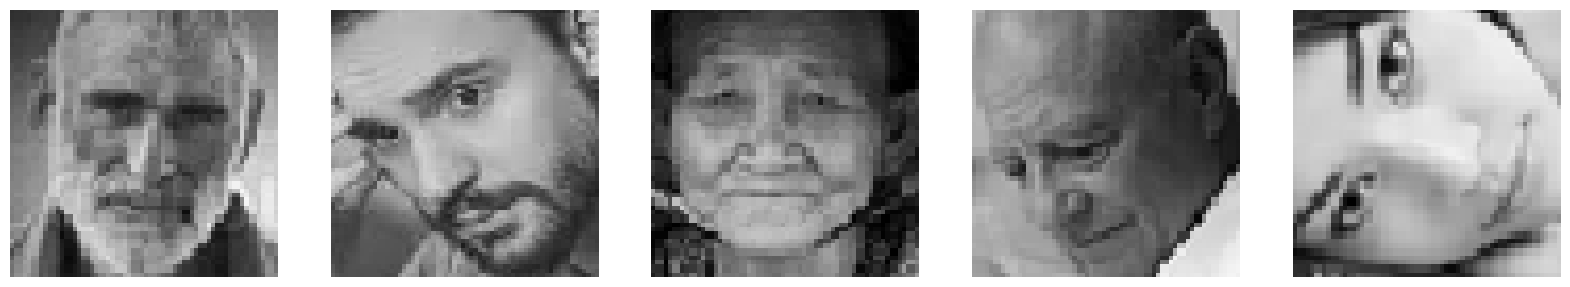

In [185]:
images = X_train[:5]
print(f"images shape : {images.shape}")
show_images(images, None, len(images))

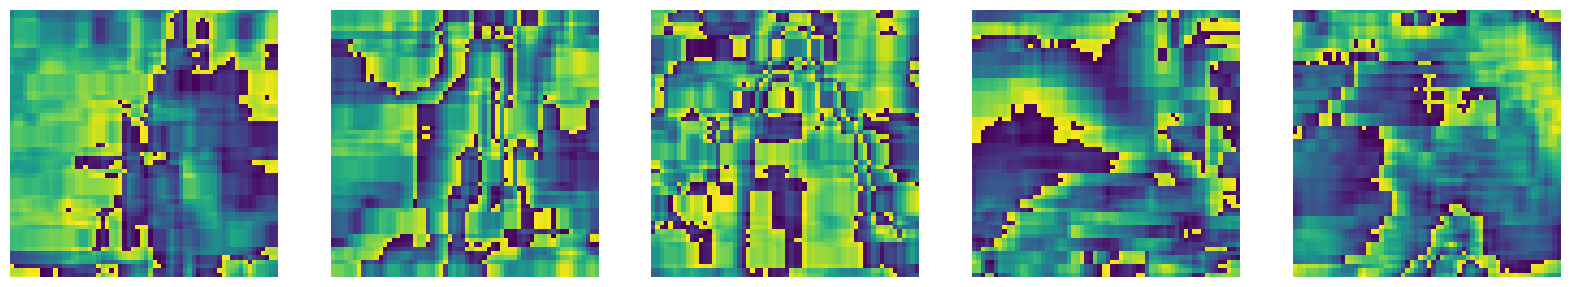

In [183]:
reshaped_images = images.reshape((len(images),3,64,64))

kernel = np.array([
    [1, 1, 0],
    [1, 1, 0],
    [1, 1, 0]
])

# Appliquer correlate2d à chaque couche de chaque image
conv_images = []
for img in reshaped_images:
    conv_img = []
    for layer in img:
        conv_layer = correlate2d(layer, kernel, 'valid')
        conv_img.append(conv_layer)
    conv_images.append(np.array(conv_img))

# Redimensionner les images convoluées pour les afficher
conv_images_to_show = np.array(conv_images).reshape(-1, 64 - 3 + 1, 64 - 3 + 1)

show_images(conv_images_to_show,None, len(images))

In [186]:
X_train.shape

(10500, 64, 64, 3)

In [188]:
def preprocess_images(X):
    X_normalized = X / 255.0
    X_reshaped = X.reshape(len(X), 3, 64, 64)
    return X_reshaped

X_train_preprocessed = preprocess_images(X_train)
X_test_preprocessed = preprocess_images(X_test)

print(f"X_train_preprocessed shape: {X_train_preprocessed.shape}")
print(f"X_test_preprocessed shape: {X_test_preprocessed.shape}")

X_train_preprocessed shape: (10500, 3, 64, 64)
X_test_preprocessed shape: (4500, 3, 64, 64)


In [195]:
network = np.array([my_lib.create_ConvLayer(3, 64, 64, 
                                            3,
                                            32), 
                    my_lib.create_ActivationLayer("tanh".encode('utf-8')),
                    my_lib.create_MaxPoolingLayer(2),
                    
                    my_lib.create_FlattenLayer(),
                    
                    my_lib.create_DenseLayer(30752, 10),
                    my_lib.create_ActivationLayer("tanh".encode('utf-8'))
                   ])

c_network = network.ctypes.data_as(ctypes.POINTER(ctypes.c_void_p))
network_size = ctypes.c_int(len(network))
loss_name = "mse".encode('utf-8')

model = my_lib.create_MyCNN(c_network, network_size, loss_name)

(n_input, input_depth, input_height, input_width) = X_train.shape
y_dim = y_train.shape[1]
n_images_test = len(x_test)

Layer Type: Convolutional
Layer Type: Activation
Layer Type: MaxPooling
Layer Type: Flatten
Layer Type: Dense
Layer Type: Activation


In [196]:
def interrop_processing(X_train, y_train):
    n_input, input_depth, input_height, input_width = X_train.shape
    _,y_dim = y_train.shape
    
    X_train_flatten = np.array(X_train, np.float64).flatten()
    y_train_flatten = np.array(y_train, np.float64).flatten()
    
    c_X_train = np.ctypeslib.as_ctypes(X_train_flatten)
    c_y_train = np.ctypeslib.as_ctypes(y_train_flatten)

    return c_X_train, c_y_train

c_X_train, c_y_train = interrop_processing(X_train, y_train)
c_X_test, c_y_test = interrop_processing(x_test, y_test)

In [ ]:
epochs = 5
learning_rate = 0.01

my_lib.train_MyCNN(model,
                   
                   c_X_train, 
                   n_input, 
                   input_depth, 
                   input_height, 
                   input_width, 
                   
                   c_y_train, 
                   y_dim,

                   c_X_train,
                   n_images_test,

                   c_y_test,
                   learning_rate,
                   epochs)

# MNIST Test

In [175]:
import numpy as np
import keras
from keras import layers
    
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(X_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.reshape(len(X_train), 1, 28, 28)
x_test = x_test.reshape(len(x_test), 1, 28, 28)

# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
print("X_train shape:", X_train.shape)
print(X_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 1, 28, 28)
60000 train samples
10000 test samples


In [ ]:
import numpy as np
import keras
from keras import layers
    
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(X_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.reshape(len(X_train), 1, 28, 28)
x_test = x_test.reshape(len(x_test), 1, 28, 28)

# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
print("X_train shape:", X_train.shape)
print(X_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


network = np.array([my_lib.create_ConvLayer(1, 28, 28, 
                                            3,
                                            32), 
                    my_lib.create_ActivationLayer("tanh".encode('utf-8')),
                    my_lib.create_MaxPoolingLayer(2),

                    my_lib.create_ConvLayer(32, 25, 25, 
                                            2,
                                            64), 
                    my_lib.create_ActivationLayer("tanh".encode('utf-8')),
                    my_lib.create_MaxPoolingLayer(2),
                    
                    my_lib.create_FlattenLayer(),
                    
                    my_lib.create_DenseLayer(33_856,10),
                    my_lib.create_ActivationLayer("tanh".encode('utf-8'))
                   ])

c_network = network.ctypes.data_as(ctypes.POINTER(ctypes.c_void_p))
network_size = ctypes.c_int(len(network))
loss_name = "mse".encode('utf-8')

model = my_lib.create_MyCNN(c_network, network_size, loss_name)

(n_input, input_depth, input_height, input_width) = X_train.shape
y_dim = y_train.shape[1]
n_images_test = len(x_test)

def interrop_processing(X_train, y_train):
    n_input, input_depth, input_height, input_width = X_train.shape
    _,y_dim = y_train.shape
    
    X_train_flatten = np.array(X_train, np.float64).flatten()
    y_train_flatten = np.array(y_train, np.float64).flatten()
    
    c_X_train = np.ctypeslib.as_ctypes(X_train_flatten)
    c_y_train = np.ctypeslib.as_ctypes(y_train_flatten)

    return c_X_train, c_y_train

c_X_train, c_y_train = interrop_processing(X_train, y_train)
c_X_test, c_y_test = interrop_processing(x_test, y_test)

epochs = 10
my_lib.train_MyCNN(model,
                   
                   c_X_train, 
                   n_input, 
                   input_depth, input_height,input_width, 
                   
                   c_y_train, 
                   y_dim,

                   c_X_train,
                   n_images_test,

                   c_y_test,
                   0.01,
                   epochs)